<a href="https://colab.research.google.com/github/xEzIxX/AI-Class/blob/master/week5/diabetes_DL_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 회귀 분류: BMI를 예측하는 모델

In [2]:
import pandas as pd
import numpy as np;

file_path = '/content/drive/MyDrive/Colab Notebooks/diabetes.csv'

df = pd.read_csv(file_path);
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# 정답(label) 데이터 설정
# BMI
y = df['BMI']
print(y.value_counts());

BMI
32.0    13
31.6    12
31.2    12
0.0     11
32.4    10
        ..
49.6     1
24.1     1
41.2     1
49.3     1
46.3     1
Name: count, Length: 248, dtype: int64


In [4]:
Y = y.values

In [5]:
# 입력 데이터(feature) 생성
X=df.drop('BMI',axis=1)
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,0.627,50,1
1,1,85,66,29,0,0.351,31,0
2,8,183,64,0,0,0.672,32,1
3,1,89,66,23,94,0.167,21,0
4,0,137,40,35,168,2.288,33,1


In [6]:
# 딥러닝 입력을 위해 Numpy로 변환
X = X.values

In [7]:
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

# 모델 구성
model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X.shape[1],)), # input_shape 에 숫자로 칼럼 개수 지정 가능
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(1) # 연속 값 예측이므로 활성화 함수가 없다
])

# 컴파일, 학습
model.compile(
    optimizer="adam",
    loss="mae", # 손실함수
    metrics=["mae"] #평가지표
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

y_pred = model.predict(X_test)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 31.4126 - mae: 31.4126 - val_loss: 30.2359 - val_mae: 30.2359
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 28.9240 - mae: 28.9240 - val_loss: 26.8030 - val_mae: 26.8030
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 23.7835 - mae: 23.7835 - val_loss: 19.8426 - val_mae: 19.8426
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 15.1275 - mae: 15.1275 - val_loss: 10.8706 - val_mae: 10.8706
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.0853 - mae: 9.0853 - val_loss: 7.0391 - val_mae: 7.0391
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.3538 - mae: 7.3538 - val_loss: 6.2366 - val_mae: 6.2366
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.7051 - mae: 6.7051 - val_loss: 6.1322 - val_mae: 6.1322
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.6652 - mae: 6.6652 - val_loss: 5.8829 - val_mae: 5.8829
Epoch 9/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss

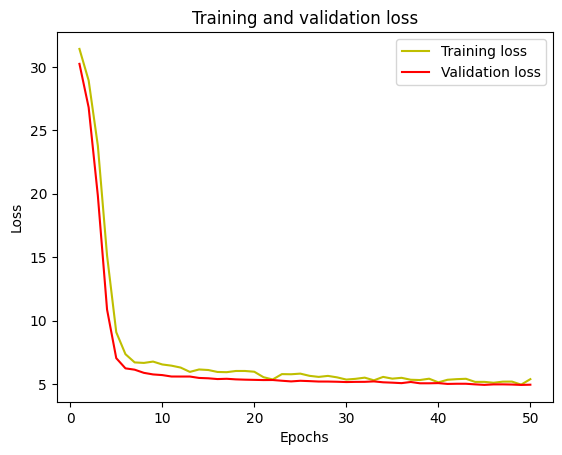

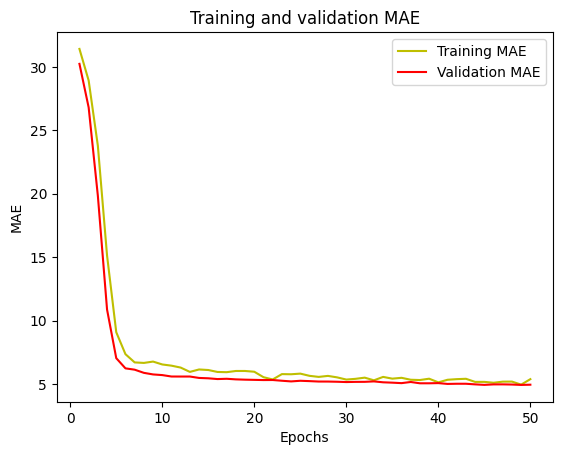

MAE : 4.823400058994045
MSE : 46.96077619347597
RMSE: 6.852793313202724


In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

loss = history.history['loss']
val_loss = history.history['val_loss']
mae = history.history['mae']
val_mae = history.history['val_mae']
epochs = range(1, len(loss) + 1)

# loss 그래프
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# MAE 그래프
plt.plot(epochs, mae, 'y', label='Training MAE')
plt.plot(epochs, val_mae, 'r', label='Validation MAE')
plt.title('Training and validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

# 회귀 평가지표
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)